In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_final.csv')
print(f"full dataframe:\n{df}\n")
print(f"full dataframe columns:\n{df.columns.tolist()}\n")
print(f"full dataframe describe:\n{df.describe()}\n")
print(f"full dataframe info:\n{df.info()}\n")

full dataframe:
       Unnamed: 0  index       post_id source_platform  \
0               0      0  10001291_gab             gab   
1               1      1  10002346_gab             gab   
2               2      3  10008196_gab             gab   
3               3      4  10009556_gab             gab   
4               4      5  10010219_gab             gab   
...           ...    ...           ...             ...   
19224       19224  20143   9991681_gab             gab   
19225       19225  20144   9992513_gab             gab   
19226       19226  20145   9993012_gab             gab   
19227       19227  20146   9995600_gab             gab   
19228       19228  20147   9998729_gab             gab   

                                               post_text  token_count  \
0      jews are responsible for destroying my towns c...           22   
1      leftist mind control fails i think this overst...           33   
2      it why they behave like animals no matter wher...           5

In [3]:
print(f"Missing Values:\n{df.isnull().sum()}\n")
print(f"Total duplicates:\n{df.duplicated().sum()}\n")
print(f"Unique Values per Column:\n{df.nunique()}")

Missing Values:
Unnamed: 0                      0
index                           0
post_id                         0
source_platform                 0
post_text                       0
token_count                     0
majority_label                  0
normal_votes                    0
offensive_votes                 0
hatespeech_votes                0
annotator_1_label               0
annotator_1_targets_text     6874
annotator_2_label               0
annotator_2_targets_text     6783
annotator_3_label               0
annotator_3_targets_text     6832
rationale_count                 0
post_tokens                     0
annotator_count                 0
rationales                      0
labels                          0
annotator_1_id                  0
annotator_1_targets             0
annotator_2_id                  0
annotator_2_targets             0
annotator_3_id                  0
annotator_3_targets             0
rationale_1                  7814
rationale_2                  781

In [4]:
print(f"Majority Label Distribution:\n{df['majority_label'].value_counts(normalize=True) * 100}\n")
print(f"Source Platform Distribution:\n{df['source_platform'].value_counts()}")

Majority Label Distribution:
majority_label
normal        40.636539
hatespeech    30.864840
offensive     28.498622
Name: proportion, dtype: float64

Source Platform Distribution:
source_platform
gab        10423
twitter     8778
nf            28
Name: count, dtype: int64


In [5]:
print(f"Token Count Stats by Label:\n{df.groupby('majority_label')['token_count'].describe()}\n")
print(f"Extremely Short Posts (Under 3 tokens):\n{df[df['token_count'] < 3][['post_text', 'majority_label']]}")

Token Count Stats by Label:
                 count       mean        std  min   25%   50%   75%    max
majority_label                                                            
hatespeech      5935.0  24.568492  14.080561  2.0  13.0  22.0  36.0  165.0
normal          7814.0  23.319427  13.677442  2.0  12.0  20.0  34.0   70.0
offensive       5480.0  22.362226  13.528228  2.0  11.0  19.0  32.0   76.0

Extremely Short Posts (Under 3 tokens):
             post_text majority_label
6503     cannot change         normal
8192     bitches pussy      offensive
12793         lol kike     hatespeech
14034  cheeky chinaman      offensive


In [6]:
def check_consensus(row):
    return 3 in [row['normal_votes'], row['offensive_votes'], row['hatespeech_votes']]

df['is_unanimous'] = df.apply(check_consensus, axis=1)

print(f"Annotator Consensus: Percentage of unanimous decisions: {df['is_unanimous'].mean() * 100:.2f}%")
contentious = df[(df['normal_votes'] == 1) & (df['offensive_votes'] == 1) & (df['hatespeech_votes'] == 1)]
print(f"Most Contentious Posts (Mixed Votes): Number of posts with a 1-1-1 vote split: {len(contentious)}")

Annotator Consensus: Percentage of unanimous decisions: 51.20%
Most Contentious Posts (Mixed Votes): Number of posts with a 1-1-1 vote split: 0


In [7]:
print(f"Sample of Majority Targets:\n{df['majority'].value_counts().head(10)}\n")

Sample of Majority Targets:
majority
['Other']      7827
['African']    2091
['Islam']      1394
['Jewish']     1261
['LGBTQ']      1179
['Women']       874
['Refugee']     612
['Arab']        312
[]              267
['Asian']       266
Name: count, dtype: int64



In [3]:
# Imports
import ast
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score, roc_auc_score, log_loss
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, TensorDataset
from transformers import AutoTokenizer
from tqdm.notebook import tqdm
from models import Model_Rational_Label
from pathlib import Path

warnings.filterwarnings("ignore")

# Constants:
HF_MODEL = "Hate-speech-CNERG/bert-base-uncased-hatexplain-rationale-two"
MAX_LEN = 128
BATCH_SIZE = 32
MLP_EPOCHS = 60 
MLP_LR = 1e-3
LABEL2ID = {"normal": 0, "offensive": 1, "hatespeech": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COLORS = {"normal": "blue", "offensive": "green", "hatespeech": "red"}
alpha_lvl = 0.6

COMMUNITY_TABLE = {
    "Asexual":"LGBTQ", "Bisexual":"LGBTQ", "Homosexual":"LGBTQ",
    "Buddhism":"Other", "Indigenous":"Other", "Economic":"Other",
    "Heterosexual":"Other","Hindu":"Other","Nonreligious":"Other",
    "None":"Other","Minority":"Other","Disability":"Other",
    "Christian":"Other","Men":"Other",
    "Indian":"Asian","Asian":"Asian",
    "Hispanic":"Hispanic","Caucasian":"Caucasian",
    "Arab":"Arab","Refugee":"Refugee",
    "Other":"Other","Jewish":"Jewish","Women":"Women",
    "Islam":"Islam","African":"African",
}

# Cache paths — embeddings saved here after first run
EMBED_CACHE = Path("cls_embeddings.npy")
LABEL_CACHE = Path("cls_labels.npy")

print(f"Device: {DEVICE}")


# Helpers:
def safe_parse_list(val):
    if pd.isna(val): return []
    if isinstance(val, list): return val
    try: return ast.literal_eval(str(val))
    except: return []

def safe_parse_rationale(val):
    if pd.isna(val): return None
    try: return np.array(ast.literal_eval(str(val)), dtype=np.float32)
    except: return None

def build_ground_truth_attention(row, temperature=5.0):
    L = int(row["token_count"])
    if row["majority_label"] == "normal":
        return np.ones(L, dtype=np.float32) / L
    vecs = []
    for col in ["rationale_1","rationale_2","rationale_3"]:
        v = safe_parse_rationale(row[col])
        if v is not None and len(v) == L:
            vecs.append(v)
    if not vecs:
        return np.ones(L, dtype=np.float32) / L
    avg = np.mean(vecs, axis=0)
    scaled = avg / temperature
    shifted = scaled - scaled.max()
    exp_v = np.exp(shifted)
    return (exp_v / exp_v.sum()).astype(np.float32)

def normalise_community(targets_str):
    raw = safe_parse_list(targets_str)
    return list({COMMUNITY_TABLE.get(t, "Other") for t in raw})

def load_and_preprocess(csv_path, sample_n=None):
    # print(f"\nLoading {csv_path}")
    df = pd.read_csv(csv_path)
    valid = set(LABEL2ID.keys())
    df = df[df["majority_label"].isin(valid)].reset_index(drop=True)
    df = df[df["source_platform"].isin(["gab","twitter"])].reset_index(drop=True)
    df["label_id"] = df["majority_label"].map(LABEL2ID)
    df["gt_attention"] = df.apply(build_ground_truth_attention, axis=1)
    df["majority_norm"] = df["majority"].apply(normalise_community)
    if sample_n and sample_n < len(df):
        df = (df.groupby("majority_label", group_keys=False)
                .apply(lambda g: g.sample(int(sample_n*len(g)/len(df)), random_state=42))
                .reset_index(drop=True))
    print(f"Rows: {len(df):,}")
    for lbl, cnt in df["majority_label"].value_counts().items():
        print(f"{lbl:<12} {cnt:>5}  ({cnt/len(df)*100:.1f}%)")
    return df


class PostDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, padding="max_length", truncation=True, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

@torch.no_grad()
def extract_cls_embeddings(model, dataloader, device):
    model.eval()
    all_emb, all_lbl = [], []
    for batch in tqdm(dataloader, desc="  Extracting CLS"):
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        last_hidden = model.bert(input_ids, attention_mask=attn_mask)[0]
        pooled = model.bert_pooler(last_hidden)
        all_emb.append(pooled.cpu().numpy())
        all_lbl.append(batch["label"].numpy())
    return np.vstack(all_emb), np.concatenate(all_lbl)


# MLP:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=768, hidden_dims=(256,64), num_classes=3, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_mlp(X_train, y_train, X_val, y_val, epochs=MLP_EPOCHS, lr=MLP_LR, device=DEVICE):
    mlp = MLPClassifier().to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xvl = torch.tensor(X_val,   dtype=torch.float32)
    train_dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    best_val_acc, best_state = 0.0, None
    # ── track metrics for plotting ────────────────────────────────────────────
    history = {"epoch": [], "loss": [], "val_acc": [], "lr": []}

    print(f"\nTraining MLP ({epochs} epochs):\n")
    for epoch in range(1, epochs+1):
        mlp.train()
        total_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(mlp(xb), yb)
            loss.backward(); opt.step()
            total_loss += loss.item()
        mlp.eval()
        with torch.no_grad():
            val_preds = mlp(Xvl.to(device)).argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(y_train if False else y_val, val_preds)
        sched.step(val_acc)
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in mlp.state_dict().items()}
        current_lr = opt.param_groups[0]['lr']
        history["epoch"].append(epoch)
        history["loss"].append(total_loss / len(train_dl))
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)
        print(f"Epoch {epoch:02d}/{epochs} | loss: {total_loss/len(train_dl):.4f}"
              f" | val_acc: {val_acc:.4f} | lr: {current_lr:.2e}" + (" (best)" if is_best else ""))
    mlp.load_state_dict(best_state)
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
    # attach history to model so it's accessible after the call
    mlp.history = history
    return mlp

# Inference 
@torch.no_grad()
def predict(text, bert_model, mlp_model, tokenizer, device, top_k=5):
    bert_model.eval(); mlp_model.eval()
    enc = tokenizer(text, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attn_mask = enc["attention_mask"].to(device)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    _, rationale_logits = bert_model(input_ids=input_ids, attention_mask=attn_mask)
    last_hidden = bert_model.bert(input_ids, attention_mask=attn_mask)[0]
    cls_emb = bert_model.bert_pooler(last_hidden)
    mlp_logits = mlp_model(cls_emb)
    class_probs = torch.softmax(mlp_logits, dim=-1).squeeze()
    pred_id = int(class_probs.argmax())
    rationale_probs  = torch.softmax(rationale_logits, dim=-1)
    rationale_scores = rationale_probs[0, :, 1].cpu().numpy()
    real_mask = attn_mask[0].cpu().numpy() == 1
    skip = {"[CLS]","[SEP]","[PAD]"}
    real_tokens = [
        (tokens[i], float(rationale_scores[i]))
        for i in range(len(tokens))
        if real_mask[i] and tokens[i] not in skip
    ]
    top_tokens = sorted(real_tokens, key=lambda x: x[1], reverse=True)[:top_k]
    return {
        "label":       ID2LABEL[pred_id],
        "class_probs": {ID2LABEL[i]: round(float(p),4) for i,p in enumerate(class_probs.cpu())},
        "important_tokens":     [(t, round(s,4)) for t,s in top_tokens],
        "all_rationale_scores": [(t, round(s,4)) for t,s in real_tokens],
    }

# CLAUDE Table Print:
def pretty_print_prediction(result, text):
    print(f"\n  ┌─ Input ─────────────────────────────────────────────")
    print(f"  │  {text}")
    print(f"  ├─ Predicted label: {result['label'].upper()}")
    probs = result["class_probs"]
    print(f"  │  normal:     {probs['normal']:.4f}")
    print(f"  │  offensive:  {probs['offensive']:.4f}")
    print(f"  │  hatespeech: {probs['hatespeech']:.4f}")
    print(f"  ├─ Top-{len(result['important_tokens'])} model‑identified important tokens:")
    for tok, score in result["important_tokens"]:
        bar = "█" * int(score*40)
        print(f"  │    {tok:<20} {score:.4f}  {bar}")
    print(f"  └────────────────────────────────────────────────────")


def eda_plots():    
    df_eda = pd.read_csv("df_final.csv")
    df_eda = df_eda[df_eda["majority_label"].isin(LABEL2ID.keys())].reset_index(drop=True)
    df_eda = df_eda[df_eda["source_platform"].isin(["gab","twitter"])].reset_index(drop=True)
    df_eda["label_id"] = df_eda["majority_label"].map(LABEL2ID)
    df_eda["token_count"] = df_eda["token_count"].astype(int)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("EDA HateXplain Dataset", fontsize=14, y=1.01)
    
    # label distribution
    label_counts = df_eda["majority_label"].value_counts().reindex(["normal","offensive","hatespeech"])
    axes[0,0].bar(label_counts.index, label_counts.values, color=[COLORS[l] for l in label_counts.index], edgecolor="white", alpha=alpha_lvl)
    axes[0,0].set_title("Label Distribution")
    axes[0,0].set_ylabel("Count")
    for i, v in enumerate(label_counts.values):
        axes[0,0].text(i, v + 80, f"{v:,}\n({v/len(df_eda)*100:.1f}%)", ha="center", fontsize=9)
    
    # platform distribution
    plat_counts = df_eda["source_platform"].value_counts()
    axes[0,1].bar(plat_counts.index, plat_counts.values, color=["blue","green"], edgecolor="white", alpha=alpha_lvl)
    axes[0,1].set_title("Platform Distribution")
    axes[0,1].set_ylabel("Count")
    for i, v in enumerate(plat_counts.values):
        axes[0,1].text(i, v + 80, f"{v:,}", ha="center", fontsize=9)
    
    # label x platform stacked bar
    plat_label = df_eda.groupby(["source_platform","majority_label"]).size().unstack(fill_value=0)
    plat_label = plat_label[["normal","offensive","hatespeech"]]
    bottom = np.zeros(len(plat_label))
    for lbl in ["normal","offensive","hatespeech"]:
        axes[0,2].bar(plat_label.index, plat_label[lbl], bottom=bottom, label=lbl, color=COLORS[lbl], edgecolor="white", alpha=alpha_lvl)
        bottom += plat_label[lbl].values
    axes[0,2].set_title("Label Split by Platform")
    axes[0,2].set_ylabel("Count")
    axes[0,2].legend(fontsize=8)
    
    # token count distribution by label
    for lbl, grp in df_eda.groupby("majority_label"):
        axes[1,0].hist(grp["token_count"].clip(upper=80), bins=40, alpha=0.4, label=lbl, color=COLORS[lbl], edgecolor="none")
    axes[1,0].set_title("Token Count Distribution (clipped at 80)")
    axes[1,0].set_xlabel("Token count")
    axes[1,0].set_ylabel("Frequency")
    axes[1,0].legend(fontsize=8)
    
    # median token count per label
    med_tokens = df_eda.groupby("majority_label")["token_count"].median().reindex(["normal","offensive","hatespeech"])
    axes[1,1].bar(med_tokens.index, med_tokens.values, color=[COLORS[l] for l in med_tokens.index], edgecolor="white", alpha=alpha_lvl)
    axes[1,1].set_title("Median Token Count per Label")
    axes[1,1].set_ylabel("Median tokens")
    for i, v in enumerate(med_tokens.values):
        axes[1,1].text(i, v + 0.3, f"{v:.0f}", ha="center", fontsize=9)
    
    # rationale coverage: fraction of posts with at least one rationale annotated
    def has_rationale(row):
        for col in ["rationale_1","rationale_2","rationale_3"]:
            v = safe_parse_rationale(row[col])
            if v is not None and v.sum() > 0:
                return True
        return False
    
    rat_cols = ["rationale_1","rationale_2","rationale_3"]
    df_eda["has_rat"] = df_eda[rat_cols].notna().any(axis=1)
    rat_by_label = df_eda.groupby("majority_label")["has_rat"].mean().reindex(["normal","offensive","hatespeech"])
    axes[1,2].bar(rat_by_label.index, rat_by_label.values * 100, color=[COLORS[l] for l in rat_by_label.index], edgecolor="white", alpha=alpha_lvl)
    axes[1,2].set_title("Rationale Annotation Coverage (%)")
    axes[1,2].set_ylabel("% of posts with rationale")
    axes[1,2].set_ylim(0, 110)
    for i, v in enumerate(rat_by_label.values):
        axes[1,2].text(i, v*100 + 1.5, f"{v*100:.1f}%", ha="center", fontsize=9)
    
    plt.tight_layout()
    plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
    plt.show()


def mlp_training(epochs_x, hist, best_epoch):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("MLP Training w/ 60 Epochs on Frozen BERT Embeddings", fontsize=13)

    axes[0].plot(epochs_x, hist["loss"], color="blue", linewidth=1.5, alpha=alpha_lvl)
    axes[0].axvline(best_epoch, color="grey", linestyle="--", linewidth=1,
                    label=f"Best epoch ({best_epoch})")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend(fontsize=8)

    axes[1].plot(epochs_x, hist["val_acc"], color="red", linewidth=1.5, alpha=alpha_lvl)
    axes[1].axvline(best_epoch, color="grey", linestyle="--", linewidth=1)
    axes[1].axhline(max(hist["val_acc"]), color="red", linestyle=":", linewidth=1,
                    label=f"Best val acc: {max(hist['val_acc']):.4f}")
    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.75, 0.85)
    axes[1].legend(fontsize=8)

    axes[2].plot(epochs_x, hist["lr"], color="green", linewidth=1.5, marker="o",
                 markersize=3, alpha=alpha_lvl)
    axes[2].set_title("Learning Rate Schedule")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].set_yscale("log")
    axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0e"))

    plt.tight_layout()
    plt.savefig("mlp_training.png", dpi=150, bbox_inches="tight")
    plt.show()

def post_modeling():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Post-Modeling Evaluation Test Set (n=1,921)", fontsize=13)

    # Confusion matrix – now rows/cols match label_names order
    cm = confusion_matrix(te_true_names, te_pred_names, labels=label_names)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names,
                ax=axes[0], linewidths=0.5, cbar=False)
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # Per‑class precision / recall / F1
    metrics = ["precision", "recall", "f1-score"]
    x = np.arange(len(label_names))
    width = 0.25
    metric_colors = ["brown", "violet", "orange"]
    for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
        values = [report_dict[lbl][metric] for lbl in label_names]
        axes[1].bar(x + i * width, values, width, label=metric,
                    color=color, edgecolor="white", alpha=alpha_lvl)
    axes[1].set_title("Per-Class Metrics")
    axes[1].set_xticks(x + width)
    axes[1].set_xticklabels(label_names)
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=8)
    axes[1].axhline(0.8, color="grey", linestyle="--", linewidth=0.8)

    # Confidence distribution
    winning_conf = te_probs.max(axis=1)
    for lbl, color in COLORS.items():
        mask = np.array(te_true_names) == lbl
        axes[2].hist(winning_conf[mask], bins=30, alpha=0.4,
                     label=lbl, color=color, edgecolor="none")
    axes[2].set_title("Model Confidence Distribution\n(max softmax prob, by true label)")
    axes[2].set_xlabel("Confidence")
    axes[2].set_ylabel("Count")
    axes[2].legend(fontsize=8)
    axes[2].axvline(0.5, color="grey", linestyle="--", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("post_modeling.png", dpi=150, bbox_inches="tight")
    plt.show()

def main(csv_path="df_final.csv", sample_n=None):
    """
    Complete pipeline:
    - EDA plot (external function, called first)
    - Load cache or extract BERT embeddings
    - Train/val/test split
    - Train MLP
    - Test evaluation with classification report and extended metrics
    - Plot training curves (loss, val_acc, lr)
    - Plot post‑model evaluation (confusion matrix, per‑class metrics, confidence)
    - Inference demos
    """
    train_val_test_data = {}
    eda_plots()
    print("eda_plots.png\n")

    # --- 1. Load / cache embeddings -----------------------------------------
    if EMBED_CACHE.exists() and LABEL_CACHE.exists():
        print(f"\n[Cache hit] Loading embeddings from {EMBED_CACHE}:")
        X = np.load(EMBED_CACHE)
        y = np.load(LABEL_CACHE)
        print(f"Embeddings shape: {X.shape}\nLabels shape: {y.shape}\n")
        # still need tokenizer + bert_model for inference
        print(f"\nLoading HateXplain BERT (for inference):")
        tokenizer = AutoTokenizer.from_pretrained(HF_MODEL)
        bert_model = Model_Rational_Label.from_pretrained(HF_MODEL).to(DEVICE)
        for p in bert_model.parameters():
            p.requires_grad = False
        bert_model.eval()
    else:
        df = load_and_preprocess(csv_path, sample_n=sample_n)
        texts = df["post_text"].tolist()
        labels = df["label_id"].tolist()

        print(f"\nLoading official HateXplain BERT:")
        tokenizer = AutoTokenizer.from_pretrained(HF_MODEL)
        bert_model = Model_Rational_Label.from_pretrained(HF_MODEL).to(DEVICE)
        for p in bert_model.parameters():
            p.requires_grad = False
        bert_model.eval()
        total_params = sum(p.numel() for p in bert_model.parameters())
        print(f"Loaded, Total params: {total_params:,} (all frozen)")

        print(f"\nTokenising & extracting CLS embeddings:")
        dataset = PostDataset(texts, labels, tokenizer, max_len=MAX_LEN)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        X, y = extract_cls_embeddings(bert_model, dataloader, DEVICE)
        print(f"Embeddings shape: {X.shape}\nLabels shape: {y.shape}\n")

        np.save(EMBED_CACHE, X)
        np.save(LABEL_CACHE, y)
        print(f"Saved embeddings → {EMBED_CACHE}, {LABEL_CACHE}")

    # --- 2. Split -----------------------------------------------------------
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=28, stratify=y_tmp)
    print(f"Split → train {len(X_tr):,} | val {len(X_val):,} | test {len(X_te):,}")

    train_val_test_data = {
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_val': X_val, 'y_val': y_val,
        'X_te': X_te, 'y_te': y_te
    }

    # --- 3. Train MLP -------------------------------------------------------
    mlp_model = train_mlp(X_tr, y_tr, X_val, y_val, epochs=MLP_EPOCHS, lr=MLP_LR, device=DEVICE)

    # --- 4. Plot training curves (loss, val_acc, lr) ------------------------
    hist = mlp_model.history
    epochs_x = hist["epoch"]
    best_epoch = epochs_x[hist["val_acc"].index(max(hist["val_acc"]))]
    mlp_training(epochs_x, hist, best_epoch)
    print("mlp_training.png\n")

    # --- 5. Test evaluation (report + extra metrics) -----------------------
    mlp_model.eval()
    with torch.no_grad():
        te_preds = mlp_model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE))\
                        .argmax(dim=1).cpu().numpy()
    te_true_names = [ID2LABEL[i] for i in y_te]
    te_pred_names = [ID2LABEL[i] for i in te_preds]

    print("Test-set evaluation:")
    print(classification_report(te_true_names, te_pred_names, target_names=list(LABEL2ID.keys()), digits=4))

    with torch.no_grad():
        te_probs = torch.softmax(
            mlp_model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE)), dim=-1
        ).cpu().numpy()

    bal_acc = balanced_accuracy_score(y_te, te_preds)
    mcc = matthews_corrcoef(y_te, te_preds)
    kappa = cohen_kappa_score(y_te, te_preds)
    roc_auc = roc_auc_score(y_te, te_probs, multi_class='ovr', average='macro')
    ll = log_loss(y_te, te_probs)

    print(f"Balanced accuracy: {bal_acc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Cohen's kappa: {kappa:.4f}")
    print(f"ROC AUC (macro): {roc_auc:.4f}")
    print(f"Log loss: {ll:.4f}\n")

    label_names = []
    for i in range(len(LABEL2ID)):
        label_names.append(ID2LABEL[i])

    print(f"list(LABEL2ID.keys()): {list(LABEL2ID.keys())}\n")
    print(f"label_names: {label_names}\n")
    report_dict = classification_report(te_true_names, te_pred_names, target_names=list(LABEL2ID.keys()), output_dict=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Post-Modeling Evaluation Test Set (n=1,921)", fontsize=13)

    labels = list(LABEL2ID.keys())
    cm = confusion_matrix(te_true_names, te_pred_names)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    sns.heatmap(cm_df, annot=True, fmt='d', ax=axes[0], linewidths=0.5, cmap='Blues', cbar=False)
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    
    # # confusion matrix 
    # cm = confusion_matrix(te_true_names, te_pred_names, labels=label_names)
    # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    #             xticklabels=label_names, yticklabels=label_names,
    #             ax=axes[0], linewidths=0.5, cbar=False)
    # axes[0].set_title("Confusion Matrix")
    # axes[0].set_xlabel("Predicted")
    # axes[0].set_ylabel("Actual")

    # per‑class precision / recall / F1
    metrics = ["precision", "recall", "f1-score"]
    x = np.arange(len(label_names))
    width = 0.25
    metric_colors = ["brown", "violet", "orange"]
    for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
        values = [report_dict[lbl][metric] for lbl in label_names]
        axes[1].bar(x + i * width, values, width, label=metric,
                    color=color, edgecolor="white", alpha=alpha_lvl)
    axes[1].set_title("Per-Class Metrics")
    axes[1].set_xticks(x + width)
    axes[1].set_xticklabels(label_names)
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=8)
    axes[1].axhline(0.8, color="grey", linestyle="--", linewidth=0.8)

    # confidence distribution
    winning_conf = te_probs.max(axis=1)
    for lbl, color in COLORS.items():
        mask = np.array(te_true_names) == lbl
        axes[2].hist(winning_conf[mask], bins=30, alpha=0.4,
                     label=lbl, color=color, edgecolor="none")
    axes[2].set_title("Model Confidence Distribution\n(max softmax prob, by true label)")
    axes[2].set_xlabel("Confidence")
    axes[2].set_ylabel("Count")
    axes[2].legend(fontsize=8)
    axes[2].axvline(0.5, color="grey", linestyle="--", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("post_modeling.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("post_modeling.png\n")

    # --- 7. Inference demos -------------------------------------------------
    print("\nInference Demo on New, Unseen Prompts:")
    demo_texts = [
        # Likely NORMAL
        "I love people from all walks of life.",
        "I had a great time at the cultural festival today.",
        "Everyone deserves kindness regardless of where they come from.",
        "She worked hard and earned her promotion.",
        "Let's celebrate the diversity that makes our community strong.",

        # Likely OFFENSIVE
        "Those immigrants should go back where they came from.",
        "What the hell is wrong with you, you absolute moron!",
        "This is the dumbest idea I've ever heard, what a joke.",
        "Get out of my country you don't belong here.",
        "These people are absolutely disgusting and should be ashamed.",

        # Likely HATESPEECH
        "Black people are just naturally more violent.",
        "Women belong in the kitchen, not the workplace.",
        "Jews control all the banks and media.",
        "Muslims are terrorists and should be banned from this country.",
        "Gay people are an abomination and deserve punishment.",
    ]
    for text in demo_texts:
        result = predict(text, bert_model, mlp_model, tokenizer, DEVICE, top_k=5)
        pretty_print_prediction(result, text)

    return bert_model, mlp_model, tokenizer, train_val_test_data

Device: cpu


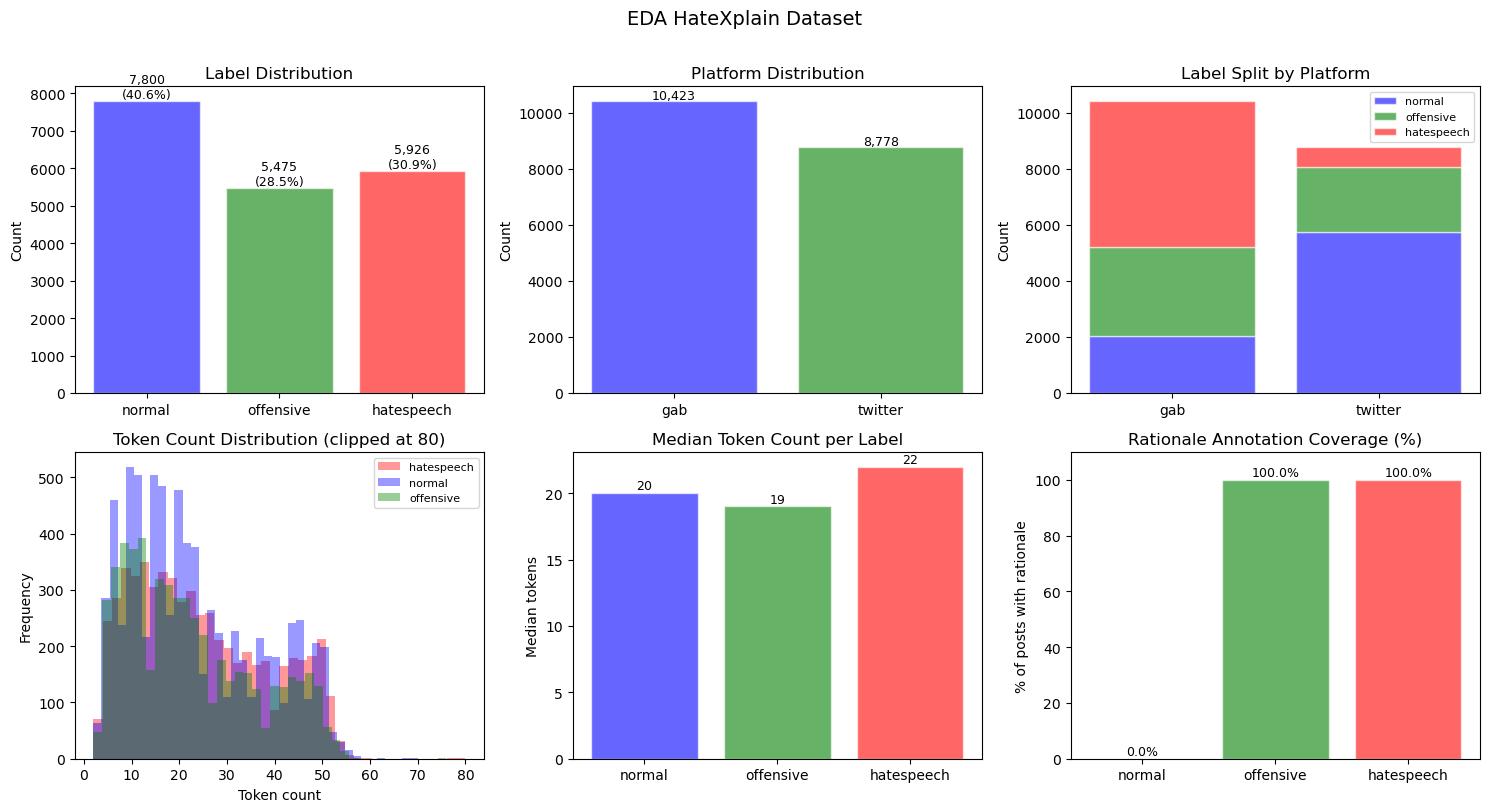

eda_plots.png


[Cache hit] Loading embeddings from cls_embeddings.npy:
Embeddings shape: (19201, 768)
Labels shape: (19201,)


Loading HateXplain BERT (for inference):


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Split → train 15,360 | val 1,920 | test 1,921

Training MLP (60 epochs):

Epoch 01/60 | loss: 0.5580 | val_acc: 0.7812 | lr: 1.00e-03 (best)
Epoch 02/60 | loss: 0.5262 | val_acc: 0.7781 | lr: 1.00e-03
Epoch 03/60 | loss: 0.5151 | val_acc: 0.7958 | lr: 1.00e-03 (best)
Epoch 04/60 | loss: 0.5083 | val_acc: 0.7958 | lr: 1.00e-03
Epoch 05/60 | loss: 0.5055 | val_acc: 0.7844 | lr: 1.00e-03
Epoch 06/60 | loss: 0.4978 | val_acc: 0.7839 | lr: 1.00e-03
Epoch 07/60 | loss: 0.5020 | val_acc: 0.7792 | lr: 1.00e-03
Epoch 08/60 | loss: 0.4941 | val_acc: 0.7901 | lr: 1.00e-03
Epoch 09/60 | loss: 0.4887 | val_acc: 0.7833 | lr: 5.00e-04
Epoch 10/60 | loss: 0.4773 | val_acc: 0.7943 | lr: 5.00e-04
Epoch 11/60 | loss: 0.4679 | val_acc: 0.8000 | lr: 5.00e-04 (best)
Epoch 12/60 | loss: 0.4623 | val_acc: 0.7870 | lr: 5.00e-04
Epoch 13/60 | loss: 0.4643 | val_acc: 0.7906 | lr: 5.00e-04
Epoch 14/60 | loss: 0.4596 | val_acc: 0.7891 | lr: 5.00e-04
Epoch 15/60 | loss: 0.4543 | val_acc: 0.7859 | lr: 5.00e-04
Epoch

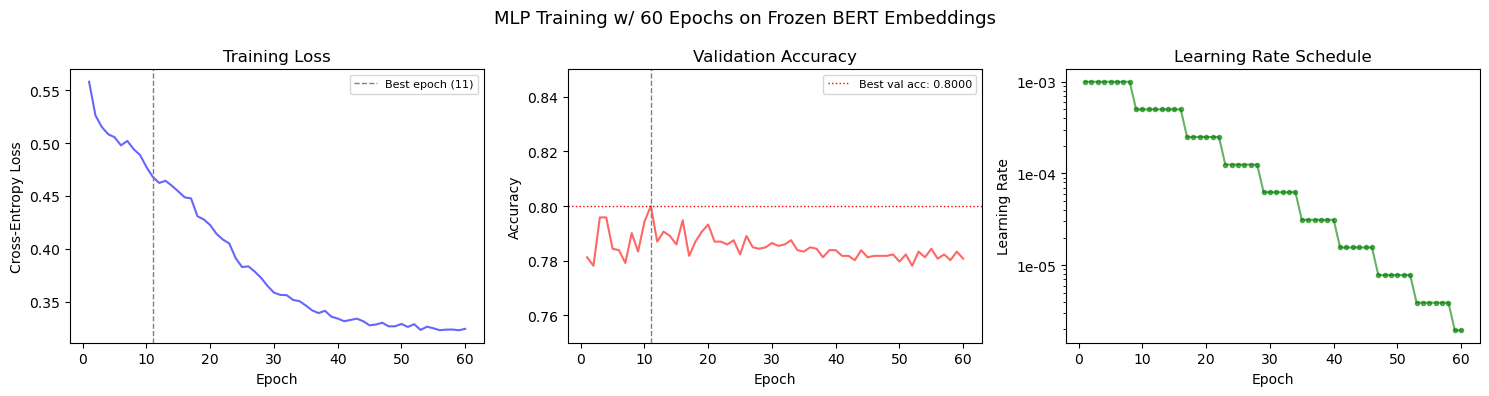

mlp_training.png

Test-set evaluation:
              precision    recall  f1-score   support

      normal     0.7752    0.7909    0.7830       593
   offensive     0.8822    0.9026    0.8923       780
  hatespeech     0.6680    0.6314    0.6492       548

    accuracy                         0.7907      1921
   macro avg     0.7751    0.7749    0.7748      1921
weighted avg     0.7881    0.7907    0.7892      1921

Balanced accuracy: 0.7749
MCC: 0.6818
Cohen's kappa: 0.6816
ROC AUC (macro): 0.9270
Log loss: 0.4793

list(LABEL2ID.keys()): ['normal', 'offensive', 'hatespeech']

label_names: ['normal', 'offensive', 'hatespeech']



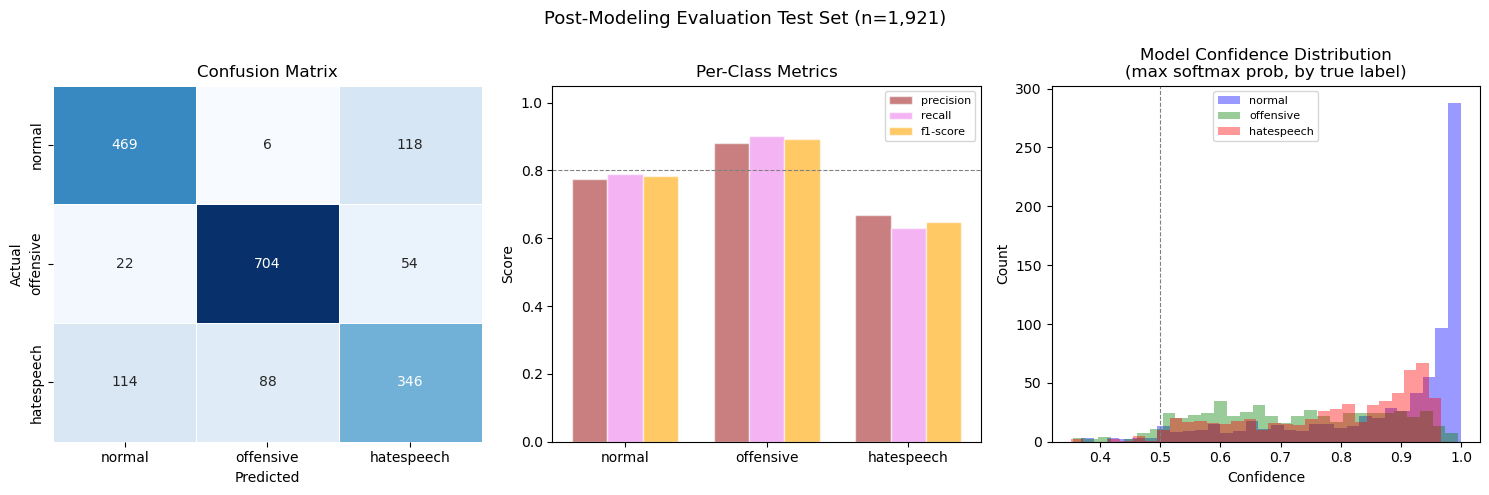

post_modeling.png


Inference Demo on New, Unseen Prompts:

  ┌─ Input ─────────────────────────────────────────────
  │  I love people from all walks of life.
  ├─ Predicted label: NORMAL
  │  normal:     0.9977
  │  offensive:  0.0021
  │  hatespeech: 0.0002
  ├─ Top-5 model‑identified important tokens:
  │    .                    0.0008  
  │    walks                0.0005  
  │    of                   0.0004  
  │    life                 0.0004  
  │    i                    0.0004  
  └────────────────────────────────────────────────────

  ┌─ Input ─────────────────────────────────────────────
  │  I had a great time at the cultural festival today.
  ├─ Predicted label: NORMAL
  │  normal:     0.9933
  │  offensive:  0.0065
  │  hatespeech: 0.0002
  ├─ Top-5 model‑identified important tokens:
  │    cultural             0.0034  
  │    festival             0.0021  
  │    had                  0.0003  
  │    great                0.0003  
  │    i                    0.0003  
  └───

In [4]:
bert_model, mlp_model, tokenizer, train_val_test_data = main(csv_path="df_final.csv")

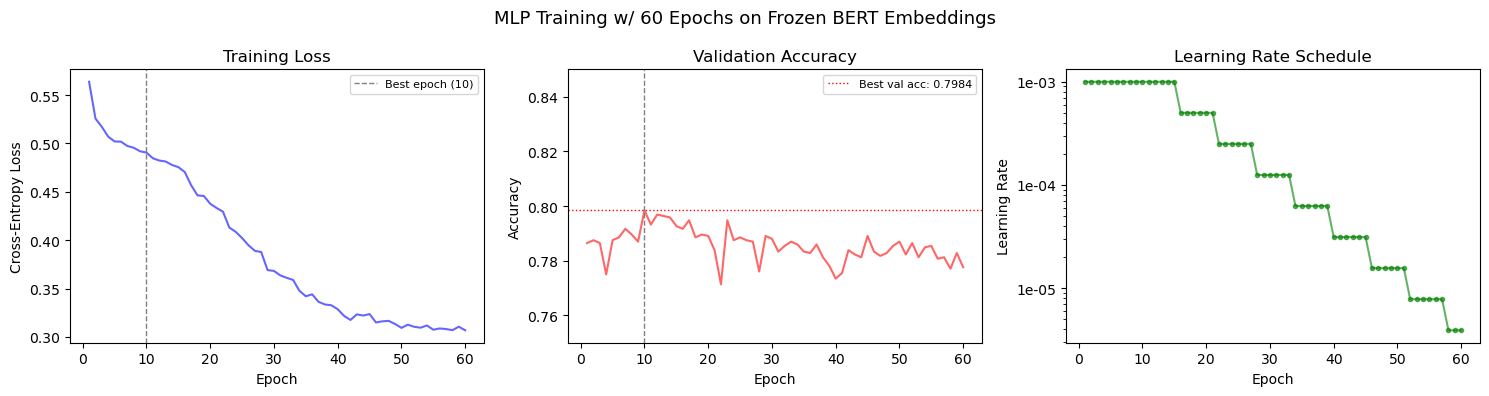

Saved: mlp_training.png


In [17]:
hist = mlp_model.history
epochs_x = hist["epoch"]
best_epoch = epochs_x[hist["val_acc"].index(max(hist["val_acc"]))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("MLP Training w/ 60 Epochs on Frozen BERT Embeddings", fontsize=13)

# training loss
axes[0].plot(epochs_x, hist["loss"], color="blue", linewidth=1.5, alpha=alpha_lvl)
axes[0].axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(fontsize=8)

# validation accuracy
axes[1].plot(epochs_x, hist["val_acc"], color="red", linewidth=1.5, alpha=alpha_lvl)
axes[1].axvline(best_epoch, color="grey", linestyle="--", linewidth=1)
axes[1].axhline(max(hist["val_acc"]), color="red", linestyle=":", linewidth=1, label=f"Best val acc: {max(hist['val_acc']):.4f}")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.75, 0.85)
axes[1].legend(fontsize=8)

# learning rate schedule
axes[2].plot(epochs_x, hist["lr"], color="green", linewidth=1.5, marker="o", markersize=3, alpha=alpha_lvl)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log")
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0e"))

plt.tight_layout()
plt.savefig("mlp_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mlp_training.png")

array([[ 0.40005487, -0.01631133, -0.46252236, ..., -0.14458007,
        -0.22685266,  0.03523793],
       [ 0.22418621, -0.48954734, -0.5762672 , ..., -0.6368825 ,
        -0.06690009,  0.09231129],
       [ 0.40854365, -0.2607321 , -0.47923407, ..., -0.4038037 ,
        -0.10783098, -0.08557673],
       ...,
       [ 0.65758306,  0.35912642,  0.08496455, ..., -0.0090763 ,
         0.37454483, -0.15278795],
       [ 0.26284862, -0.17691223, -0.5773471 , ..., -0.37294126,
        -0.10151763, -0.01239119],
       [ 0.36580098, -0.25258756, -0.4730545 , ..., -0.34200114,
        -0.0918691 , -0.03670788]], dtype=float32)

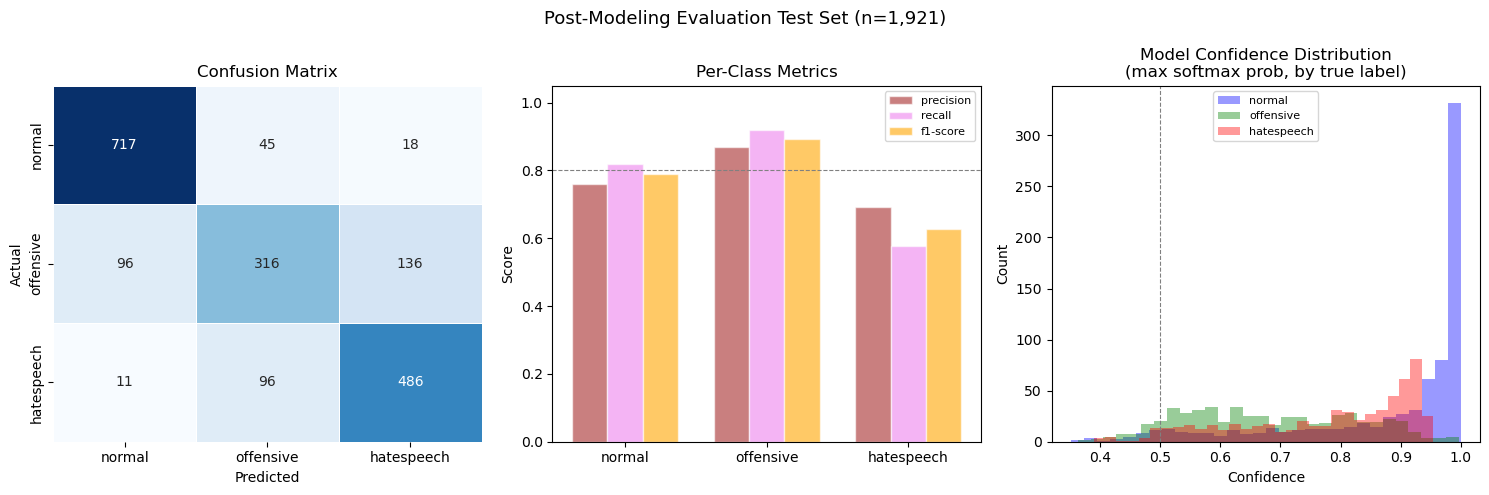

Saved: post_modeling.png


In [19]:
X_tr2, y_tr2, X_val2 = train_val_test_data['X_tr'], train_val_test_data['y_tr'], train_val_test_data['X_val'] 
y_val2, X_te2, y_te2 = train_val_test_data['y_val'], train_val_test_data['X_te'], train_val_test_data['y_te'] 

mlp_model.eval()
with torch.no_grad():
    te_preds2 = mlp_model(torch.tensor(X_te2, dtype=torch.float32).to(DEVICE)).argmax(dim=1).cpu().numpy()

label_names = ["normal", "offensive", "hatespeech"]

te_true_names = [ID2LABEL[i] for i in y_te2]
te_pred_names = [ID2LABEL[i] for i in te_preds2]

report = classification_report(
    te_true_names, te_pred_names,
    target_names=label_names, output_dict=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Post-Modeling Evaluation Test Set (n=1,921)", fontsize=13)

# confusion matrix
cm = confusion_matrix(te_true_names, te_pred_names, labels=label_names)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0], linewidths=0.5, cbar=False)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# per-class precision / recall / F1
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(label_names))
width = 0.25
metric_colors = ["brown", "violet", "orange"]
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    values = [report[lbl][metric] for lbl in label_names]
    bars = axes[1].bar(x + i*width, values, width, label=metric, color=color, edgecolor="white", alpha=alpha_lvl)
axes[1].set_title("Per-Class Metrics")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(label_names)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)
axes[1].axhline(0.8, color="grey", linestyle="--", linewidth=0.8)

# predicted class probability distributions (confidence) gather softmax probs for all test samples
mlp_model.eval()
with torch.no_grad():
    all_probs = torch.softmax(mlp_model(torch.tensor(X_te2, dtype=torch.float32).to(DEVICE)), dim=-1).cpu().numpy()

# plot distribution of winning-class confidence
winning_conf = all_probs.max(axis=1)
for lbl, color in COLORS.items():
    mask = np.array(te_true_names) == lbl
    axes[2].hist(winning_conf[mask], bins=30, alpha=0.4, label=lbl, color=color, edgecolor="none")
axes[2].set_title("Model Confidence Distribution\n(max softmax prob, by true label)")
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Count")
axes[2].legend(fontsize=8)
axes[2].axvline(0.5, color="grey", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("post_modeling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: post_modeling.png")

Confusion Matrix:
Actual Normal Count: 717 + 45 + 18 = 780
Actual Offensive Count: 96 + 316 + 136 = 548
Actual Hatespeech Count: 11 + 96 + 486 = 593